<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Tugas%20Kelompok%20MInggu%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>

<center>Laily Nissa A. Mualifah </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [ ]:
!pip install PythonTsa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from scipy.stats import boxcox,  boxcox_llf

import warnings
warnings.filterwarnings("ignore")

Untuk ilustrasi deret stasioner digunakan indeks rata-rata bulanan osilasi Atlantik Utara (NAO) sejak Januari 1950 sampai Maret 2025.

In [ ]:
link = "https://ftp.cpc.ncep.noaa.gov/cwlinks/norm.daily.nao.cdas.z500.19500101_current.csv"
nao=pd.read_csv(link)

In [ ]:
nao.head()

,year,month,day,nao_index_cdas
0,1950,1,1,0.365
1,1950,1,2,0.096
2,1950,1,3,-0.416
3,1950,1,4,-0.616
4,1950,1,5,-0.261


In [ ]:
nao.tail()

,year,month,day,nao_index_cdas
28017,2026,9,16,1.056813
28018,2026,9,17,0.858507
28019,2026,9,18,0.639971
28020,2026,9,19,0.239923
28021,2026,9,20,-0.253575


In [ ]:
#cek missing values
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,2


In [ ]:
#imputasi missing values
nao.fillna(0,inplace=True)

In [ ]:
#cek missing values
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,0


In [ ]:
#agregasi data sebagai nilai rata-rata bulanan
naos=nao.groupby(['year','month'])['nao_index_cdas'].mean()

In [ ]:
timeindex=pd.date_range('1950-01', periods=len(naos),freq='M')

In [ ]:
naos.index=timeindex

In [ ]:
naos.tail()

,nao_index_cdas
2026-05-31,-0.276665
2026-06-30,0.091036
2026-07-31,-0.049862
2026-08-31,-1.101628
2026-09-30,0.289621


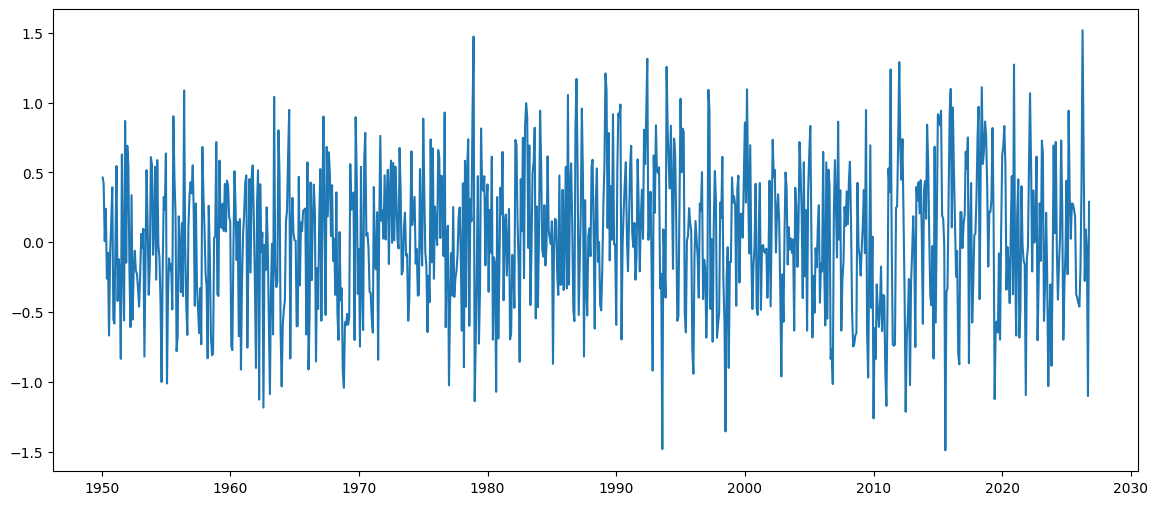

In [ ]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(naos); plt.show()

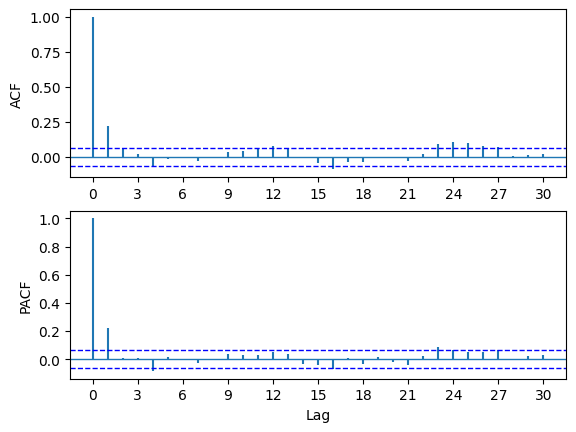

In [ ]:
#plot acf dan pacf contoh
acf_pacf_fig(naos, both=True, lag=30); plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
adfuller(naos, autolag='AIC')[1]

5.736602293407895e-28

Proses eksplorasi deret secara detail sudah dibahas pada perkuliahan minggu ke-4. Berdasarkan plot ACF dan PACF contoh tampak bahwa lag yang signifikan adalah lag 1 (baik dari ACF maupun PACF). Sehingga model yang bisa dicobakan adalah model AR (1), atau MA (1). Alat bantu identifikasi model yang lainnya adalah EACF.

In [ ]:
!pip install rpy2

In [ ]:
import warnings
warnings.filterwarnings("ignore")

#Jalankan syntax ini cukup satu kali, jangan berulang
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages('TSA')
library (TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’, ‘leaps’, ‘locfit’, ‘tseries’

trying URL 'https://cran.rstudio.com/src/contrib/xts_0.14.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TTR_0.24.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quadprog_1.5-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.9-0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quantmod_0.4.29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/leaps_3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/locfit_1.5-9.12.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tseries_0.10-63.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpM5mLaN/downloaded_packages’

Attaching package: ‘TSA’

The following objects are masked from ‘package:stats’:

    acf, arima

The f

In [ ]:
%%R -i naos
#membuat plot EACF dari data naos
eacf(as.numeric(naos))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o x o o o o o o o  x  o  o 
1 o o o x o o o o o o o  o  x  o 
2 x o x x o o o o o o o  o  o  o 
3 x x x x o o o o o o o  o  o  o 
4 x o x o o o o o o o o  o  o  o 
5 x o x x x x o o o o o  o  o  o 
6 x x o o x o o o o o o  o  o  o 
7 o x o o x x o o o o o  o  o  o 


Penentuan ordo model berdasarkan plot EACF dilakukan dengan melihat pola segitiga tanda `o`. Dari plot EACF yang didapat, terlihat segitiga yang terbentuk berada pada ordo `p=0, q=1` atau `p=1, q=0` atau `p=1, q=1`. Ordo tentatif lain seperti `p=0, q=2`, `p=1, q=2`, `p=2, q=1` juga dapat digunakan.

In [ ]:
#model MA (1)
model_ma1=ARIMA(naos,order=(0,0,1)).fit()

In [ ]:
print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -667.567
Date:                Wed, 23 Sep 2026   AIC                           1341.134
Time:                        01:05:48   BIC                           1355.611
Sample:                    01-31-1950   HQIC                          1346.658
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.020      1.386      0.166      -0.011       0.067
ma.L1          0.2133      0.033      6.555      0.000       0.150       0.277
sigma2         0.2495      0.013     19.771      0.0

Perhatikan hasil fitting model MA (1) di atas. Penduga parameter untuk komponen MA yaitu $(\theta_1)$ signifikan.

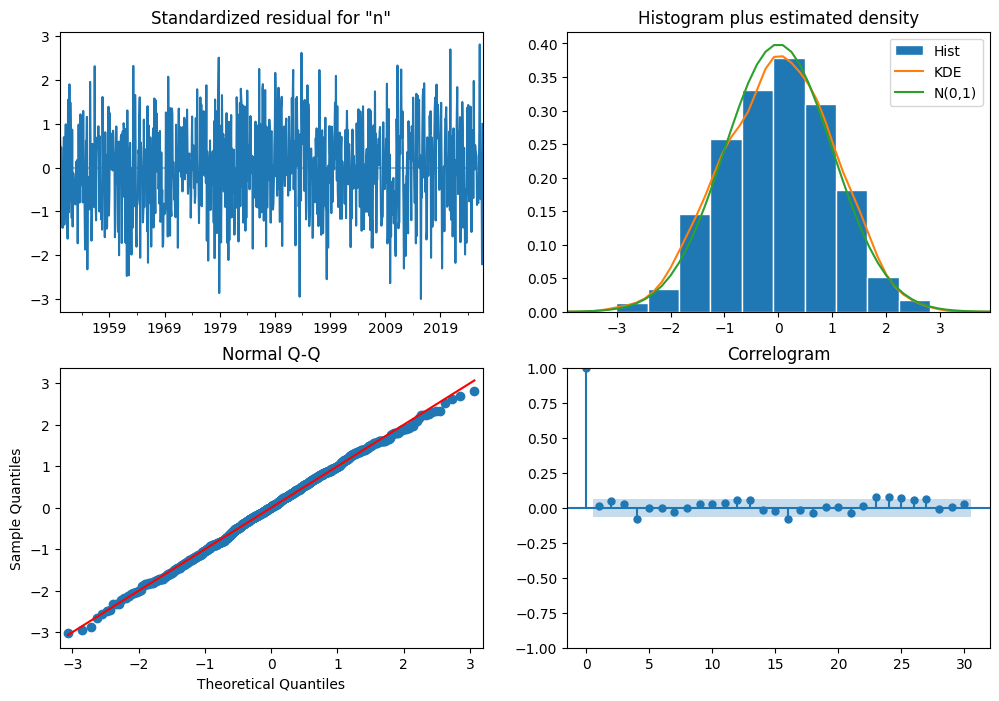

In [ ]:
#Analisis Sisaan Model
model_ma1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

In [ ]:
model_ma1.test_heteroskedasticity('breakvar')

array([[1.17473352, 0.15885655]])

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_ma1.resid, nlags=30)[1]

np.float64(0.7075739570085975)

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_ma1.resid, correction=False)

(np.float64(-0.6895162632689241), np.float64(0.4904984423946366))

In [ ]:
from scipy.stats import shapiro
stat,p = shapiro(model_ma1.resid)
print(stat,p)

0.9975654881166186 0.19122789991733924


In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ma1.resid)
print(jb_stat, jb_pval)

4.470042878863891 0.106989836027217


Apakah model MA (1) sudah memenuhi asumsi model?

Model lain yang dicobakan adalah AR (1)

In [ ]:
#model AR (1)
model_ar1=ARIMA(naos,order=(1,0,0)).fit()

In [ ]:
print(model_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -666.328
Date:                Wed, 23 Sep 2026   AIC                           1338.656
Time:                        01:05:49   BIC                           1353.132
Sample:                    01-31-1950   HQIC                          1344.180
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.309      0.190      -0.014       0.069
ar.L1          0.2225      0.032      6.993      0.000       0.160       0.285
sigma2         0.2488      0.013     19.770      0.0

Hasil fitting model AR (1) menunjukkan penduga parameter untuk komponen AR yaitu $(\phi_1)$ signifikan.

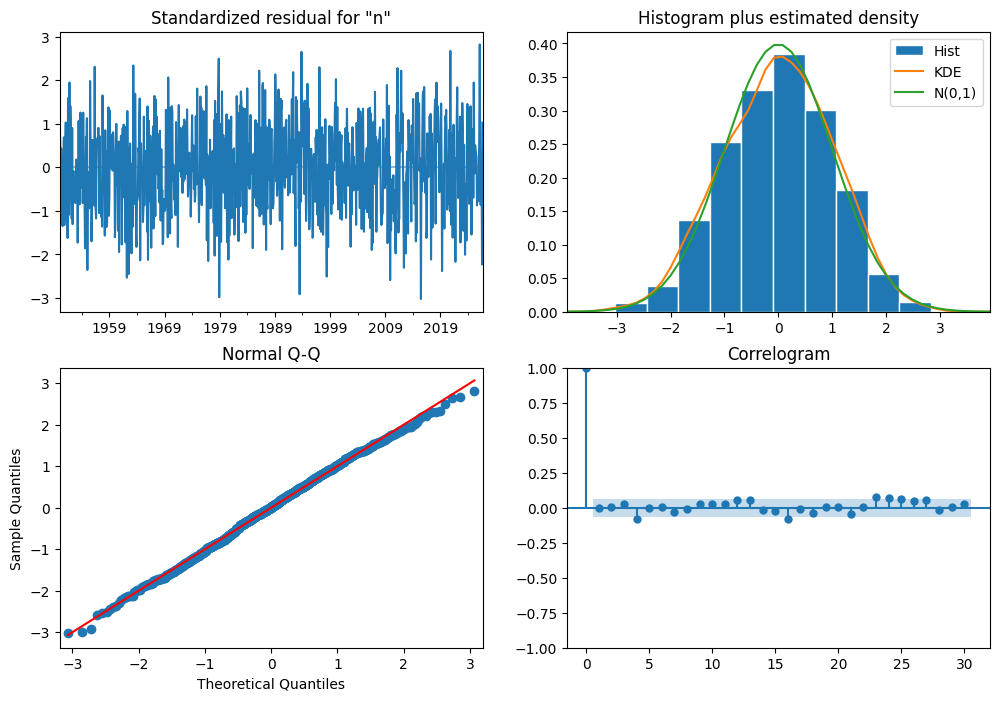

In [ ]:
#Analisis Sisaan Model
model_ar1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

In [ ]:
model_ar1.test_heteroskedasticity('breakvar')

array([[1.15925178, 0.19602124]])

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_ar1.resid, nlags=30)[1]

np.float64(0.7318397207000953)

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_ar1.resid, correction=False)

(np.float64(-0.6906357918303673), np.float64(0.48979444890637025))

In [ ]:
from scipy.stats import shapiro
stat,p = shapiro(model_ar1.resid)
print(stat,p)

0.9975637331277335 0.19074373138879314


In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ar1.resid)
print(jb_stat, jb_pval)

4.6665013202528876 0.09697998517937081


Apakah model AR (1) sudah memenuhi asumsi model?

Selanjutnya ditentukan model terbaik antara model MA (1) dan AR (1). Pemilihan model terbaik bisa berdasarkan beberapa kriteria, misalnya nilai AIC dan BIC model.

In [ ]:
pd.DataFrame({'Model':['MA(1)','AR(1)'],
            'AIC':[model_ma1.aic,model_ar1.aic],
            'BIC':[model_ma1.bic,model_ar1.bic]})

,Model,AIC,BIC
0,MA(1),1341.134420,1355.610800
1,AR(1),1338.656093,1353.132473


Berdasarkan nilai AIC dan BIC model yang lebih baik adalah model AR (1). Selanjutnya dilakukan overfitting model dengan mencobakan model AR (2).

In [ ]:
#model AR (2)
model_ar2=ARIMA(naos,order=(2,0,0)).fit()

In [ ]:
print(model_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -666.286
Date:                Wed, 23 Sep 2026   AIC                           1340.572
Time:                        01:05:50   BIC                           1359.873
Sample:                    01-31-1950   HQIC                          1347.937
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.295      0.195      -0.014       0.070
ar.L1          0.2204      0.033      6.663      0.000       0.156       0.285
ar.L2          0.0096      0.035      0.278      0.7

In [ ]:
#model ARMA (1,1)
model_arma11=ARIMA(naos,order=(1,0,1)).fit()

In [ ]:
print(model_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -666.285
Date:                Wed, 23 Sep 2026   AIC                           1340.569
Time:                        01:05:51   BIC                           1359.871
Sample:                    01-31-1950   HQIC                          1347.935
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.294      0.196      -0.014       0.070
ar.L1          0.2654      0.148      1.791      0.073      -0.025       0.556
ma.L1         -0.0451      0.155     -0.291      0.7

Hasil fitting model AR (2) maupun model ARMA (1,1) memberikan hasil bahwa penduga parameter untuk komponen AR yaitu $(\phi_2)$ dan komponen MA yaitu $(\theta_1)$ tidak signifikan, sehingga model AR (2) atau ARMA (1,1) tidak lebih baik daripada model AR (1).

In [ ]:
prediksi=model_ar1.get_forecast(12).summary_frame(alpha=0.05)

In [ ]:
prediksi

nao_index_cdas,mean,mean_se,mean_ci_lower,mean_ci_upper
2026-10-31,0.086049,0.498829,-0.891637,1.063735
2026-11-30,0.040750,0.511029,-0.960849,1.042349
2026-12-31,0.030670,0.511626,-0.972098,1.033438
2027-01-31,0.028427,0.511655,-0.974399,1.031253
2027-02-28,0.027928,0.511657,-0.974901,1.030757
2027-03-31,0.027817,0.511657,-0.975012,1.030646
2027-04-30,0.027792,0.511657,-0.975037,1.030621
2027-05-31,0.027787,0.511657,-0.975042,1.030615
2027-06-30,0.027785,0.511657,-0.975043,1.030614
2027-07-31,0.027785,0.511657,-0.975044,1.030614


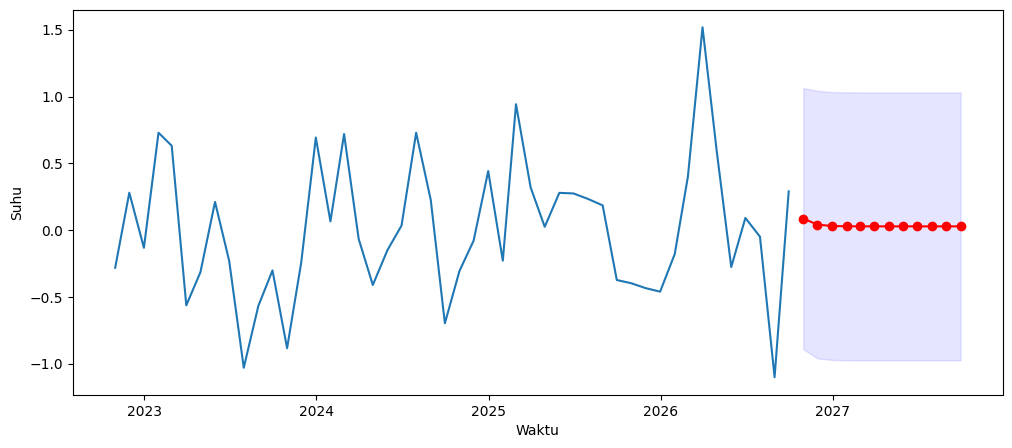

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(naos[-48:])
plt.plot(prediksi['mean'],'-or')
plt.fill_between(prediksi.index,prediksi['mean_ci_lower'], prediksi['mean_ci_upper'], color='b', alpha=.1)
plt.xlabel('Waktu'), plt.ylabel('Suhu')
plt.show()

<h2> Pemodelan dengan Pembagian Data Training dan Testing </h2>

In [ ]:
#pembagian data training testing
size_train=round(0.9*naos.shape[0])
train, test=naos[:size_train], naos[size_train:]

In [ ]:
train

,nao_index_cdas
1950-01-31,0.463516
1950-02-28,0.420714
1950-03-31,0.008387
1950-04-30,0.239433
1950-05-31,-0.261226
...,...
2018-09-30,0.768065
2018-10-31,0.404114
2018-11-30,-0.174024
2018-12-31,0.220080


In [ ]:
test

,nao_index_cdas
2019-02-28,0.299153
2019-03-31,0.818603
2019-04-30,0.193447
2019-05-31,-1.123443
2019-06-30,-0.586957
...,...
2026-05-31,-0.276665
2026-06-30,0.091036
2026-07-31,-0.049862
2026-08-31,-1.101628


In [ ]:
adfuller(train, autolag='AIC')[1]

0.0

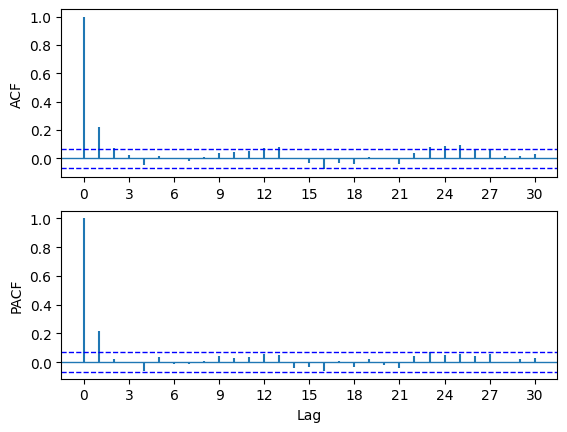

In [ ]:
acf_pacf_fig(train, both=True, lag=30); plt.show()

In [ ]:
#model MA (1)
train_ma1=ARIMA(train,order=(0,0,1)).fit()

In [ ]:
print(train_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  829
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -597.977
Date:                Wed, 23 Sep 2026   AIC                           1201.954
Time:                        01:05:52   BIC                           1216.114
Sample:                    01-31-1950   HQIC                          1207.384
                         - 01-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0298      0.021      1.424      0.154      -0.011       0.071
ma.L1          0.2032      0.034      6.028      0.000       0.137       0.269
sigma2         0.2478      0.013     18.466      0.0

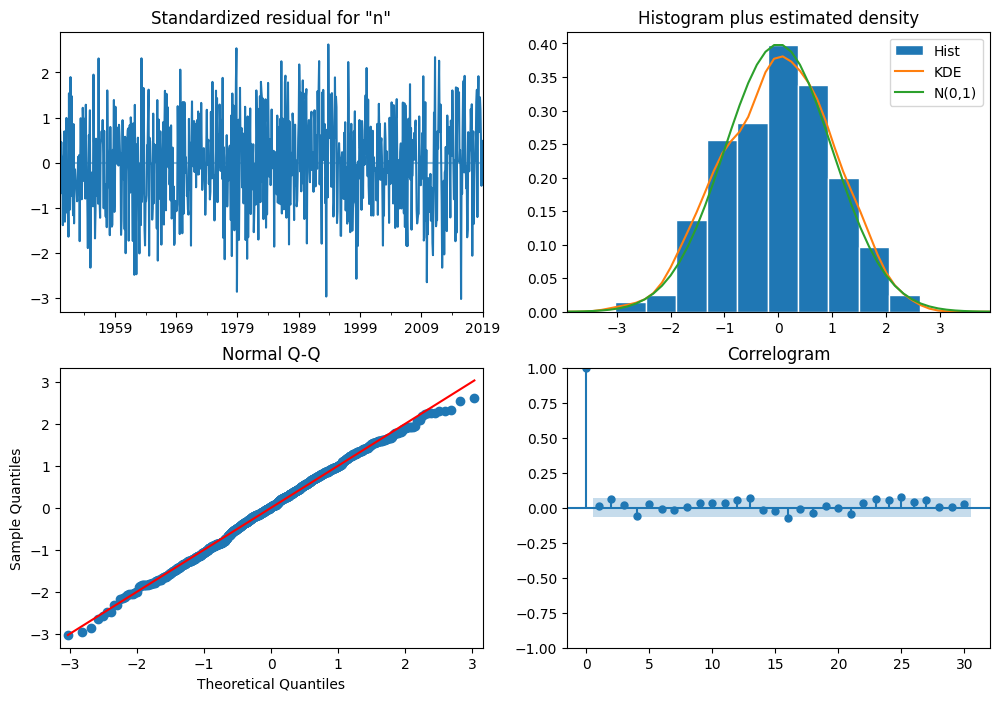

In [ ]:
train_ma1.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
het_arch(train_ma1.resid, nlags=30)[1]

np.float64(0.4843092191462428)

In [ ]:
runstest_1samp(train_ma1.resid, correction=False)

(np.float64(-0.9987155709453669), np.float64(0.3179324955138281))

In [ ]:
stat,p = shapiro(train_ma1.resid)
print(stat,p)

0.9962719526252026 0.04633899074145802


In [ ]:
train_ar1=ARIMA(train,order=(1,0,0)).fit()

In [ ]:
print(train_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  829
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -596.327
Date:                Wed, 23 Sep 2026   AIC                           1198.655
Time:                        01:05:53   BIC                           1212.816
Sample:                    01-31-1950   HQIC                          1204.086
                         - 01-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0299      0.022      1.345      0.179      -0.014       0.073
ar.L1          0.2190      0.033      6.692      0.000       0.155       0.283
sigma2         0.2468      0.013     18.477      0.0

In [ ]:
het_arch(train_ar1.resid, nlags=30)[1]

np.float64(0.5001384014614871)

In [ ]:
runstest_1samp(train_ar1.resid, correction=False)

(np.float64(-0.8655172345940554), np.float64(0.3867549606399058))

In [ ]:
stat,p = shapiro(train_ar1.resid)
print(stat,p)

0.9964149547934484 0.056446284096378384


In [ ]:
pd.DataFrame({'Model':['MA(1)','AR(1)'],
            'AIC':[train_ma1.aic,train_ar1.aic],
            'BIC':[train_ma1.bic,train_ar1.bic]})

,Model,AIC,BIC
0,MA(1),1201.953676,1216.114337
1,AR(1),1198.654863,1212.815524


In [ ]:
prediksi_test=train_ar1.get_forecast(test.shape[0]).summary_frame(alpha=0.05)

In [ ]:
prediksi_test

nao_index_cdas,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-02-28,0.070908,0.496762,-0.902728,1.044543
2019-03-31,0.038858,0.508536,-0.957854,1.035570
2019-04-30,0.031839,0.509094,-0.965967,1.029644
2019-05-31,0.030302,0.509121,-0.967556,1.028160
2019-06-30,0.029965,0.509122,-0.967895,1.027825
...,...,...,...,...
2026-05-31,0.029871,0.509122,-0.967990,1.027731
2026-06-30,0.029871,0.509122,-0.967990,1.027731
2026-07-31,0.029871,0.509122,-0.967990,1.027731
2026-08-31,0.029871,0.509122,-0.967990,1.027731


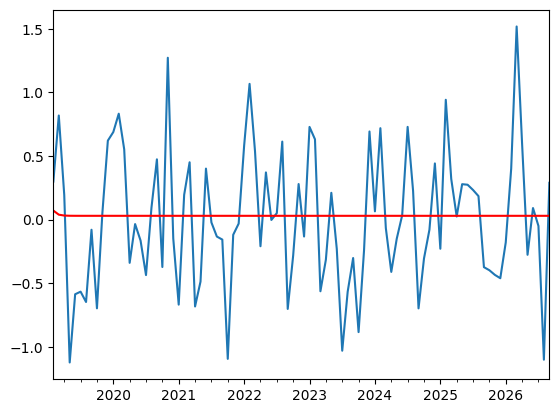

In [ ]:
test.plot()
prediksi_test['mean'].plot(color='red')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,mean_absolute_error
print('MAPE: ',mean_absolute_percentage_error(test,prediksi_test['mean'])*100, '%')
print('MSE: ',mean_squared_error(test,prediksi_test['mean']))
print('MAE: ',mean_absolute_error(test,prediksi_test['mean']))

MAPE:  114.22759505598063 %
MSE:  0.2847831022445176
MAE:  0.4293052975746584


Perhatikan bahwa nilai MAPE yang sangat besar. Berdasarkan plot perbandingan antara data test dan hasil prediksi tampak pola hasil prediksi hampir konstan sementara nilai data test sangat fluktiatif, yang berarti bahwa nilai hasil prediksi sangat jauh dari data test. Sedangkan nilai MSE dan MAE sangat kecil. Nilai MSE dan MAE akan relatif terhadap satuan data yang digunakan. Karena data naos dalam skala $10^{-1}$ sehingga nilai MSE dan MAE akan mengikuti skala tersebut.

##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok = 120.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

Pengumpulan hasil diskusi:

- melalui class.ipb.ac.id cukup perwakilan kelompok dengan format pdf. Dalam file tersebut memuat identitas anggota kelompok (Nama, NIM). Dalam file tidak perlu mencantumkan sintaks, namun menampilkan plot deret waktu dari deret simulasi dan interpretasinya; pembagian data latih data uji dan alasan pemilihan pembagian data; plot ACF, PACF, EACF, dan interpretasinya; hasil pengepasan model dan diagnostik sisaan model dan interpretasinya; plot hasil peramalan dan deret asli, nilai metrik evaluasi, dan interpretasinya.

- melalui github masing-masing anggota kelompok berupa file sintaks.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import shapiro
from sklearn.metrics import root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==============================
# INPUT SEED KELOMPOK
# ==============================
LAST_2_DIGITS = [33+37+50]  # GANTI: 2 digit terakhir NIM SEMUA anggota kelompok
SEED = int(sum(LAST_2_DIGITS))
print('Seed yang digunakan =', SEED)

Seed yang digunakan = 120


In [ ]:
def simulate_ma1(theta, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(1, n + 200):
        y[t] = e[t] + theta * e[t-1]
    return y[200:]


def simulate_ar2(phi1, phi2, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(2, n + 200):
        y[t] = phi1*y[t-1] + phi2*y[t-2] + e[t]
    return y[200:]


def simulate_arma11(phi, theta, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(1, n + 200):
        y[t] = phi*y[t-1] + e[t] + theta*e[t-1]
    return y[200:]


def mape_safe(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    mask = np.abs(actual) > 1e-8
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100


def plot_series(y, title):
    plt.figure(figsize=(12,4))
    plt.plot(y, linewidth=1)
    plt.axhline(0, linestyle='--', linewidth=0.8)
    plt.title(title)
    plt.xlabel('Waktu'); plt.ylabel('Y_t')
    plt.tight_layout(); plt.show()


def plot_acf_pacf(y, title, lags=30):
    fig, ax = plt.subplots(2, 1, figsize=(12,7))
    sm.graphics.tsa.plot_acf(y, lags=lags, ax=ax[0])
    sm.graphics.tsa.plot_pacf(y, lags=lags, ax=ax[1], method='ywm')
    ax[0].set_title(title + ' — ACF')
    ax[1].set_title(title + ' — PACF')
    plt.tight_layout(); plt.show()


def eacf_approx(y, max_p=5, max_q=5):
    """EACF-like table: residual ACF after fitting AR(p).
    'o' = residual autocorrelation at lag q tidak signifikan;
    'x' = masih signifikan. Ini digunakan sebagai pendekatan EACF
    ketika fungsi EACF khusus tidak tersedia di Python.
    """
    y = np.asarray(y)
    out = np.empty((max_p+1, max_q+1), dtype=object)
    out[:] = ''
    n = len(y)
    crit = 1.96 / np.sqrt(n)
    for p in range(max_p+1):
        if p == 0:
            resid = y - np.mean(y)
        else:
            fit = ARIMA(y, order=(p,0,0), trend='c').fit()
            resid = fit.resid
        ac = acf(resid, nlags=max_q, fft=False)
        for q in range(max_q+1):
            if q == 0:
                out[p,q] = '—'
            else:
                out[p,q] = 'o' if abs(ac[q]) <= crit else 'x'
    return pd.DataFrame(out, index=[f'p={p}' for p in range(max_p+1)],
                        columns=[f'q={q}' for q in range(max_q+1)])


def plot_eacf(table, title):
    num = table.shape[1]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.imshow(np.zeros((table.shape[0], table.shape[1])), cmap='Greys', alpha=0)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, table.iloc[i,j], ha='center', va='center', fontsize=12)
    ax.set_xticks(range(num)); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index)
    ax.set_xlabel('q'); ax.set_ylabel('p')
    ax.set_title(title + ' — EACF (aproksimasi)')
    ax.grid(True, alpha=.2)
    plt.tight_layout(); plt.show()


def fit_candidates(train):
    orders = [(0,0,1),(1,0,0),(2,0,0),(0,0,2),(1,0,1),(2,0,1),(1,0,2)]
    records = []
    fits = {}
    for order in orders:
        try:
            fit = ARIMA(train, order=order, trend='n').fit()
            lb = acorr_ljungbox(fit.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
            records.append({
                'Model': f'ARIMA{order}', 'AIC': fit.aic, 'BIC': fit.bic,
                'Ljung-Box p(10)': lb,
                'Semua parameter signifikan': bool(np.all(fit.pvalues < 0.05))
            })
            fits[order] = fit
        except Exception:
            pass
    table = pd.DataFrame(records).sort_values('BIC').reset_index(drop=True)
    return table, fits


def diagnostics(fit):
    lb = acorr_ljungbox(fit.resid, lags=[10,15,20], return_df=True)
    arch_p = het_arch(fit.resid, nlags=10)[1]
    shapiro_p = shapiro(fit.resid)[1]
    return lb, arch_p, shapiro_p


def analyze_simulation(name, y, split=0.8):
    n = len(y); n_train = int(np.floor(split*n))
    train, test = y[:n_train], y[n_train:]
    print(f'\n{name}: n={n}, train={len(train)}, test={len(test)}')
    plot_series(y, f'{name} — deret simulasi')
    plot_series(train, f'{name} — data latih')
    plot_acf_pacf(train, f'{name} — data latih', lags=min(30, len(train)//3))
    et = eacf_approx(train)
    display(et)
    plot_eacf(et, name)
    table, fits = fit_candidates(train)
    display(table.round(4))
    # Model dipilih terutama berdasarkan BIC, dengan AIC sebagai pembanding.
    best_order = table.iloc[0]['Model']
    order = eval(best_order.replace('ARIMA',''))
    fit = fits[order]
    print('Model terpilih berdasarkan BIC:', best_order)
    print(fit.summary())
    fit.plot_diagnostics(figsize=(12,8), lags=20)
    plt.suptitle(name + ' — diagnostik sisaan', y=1.02)
    plt.tight_layout(); plt.show()
    lb, arch_p, shapiro_p = diagnostics(fit)
    display(lb)
    print('p-value ARCH:', arch_p)
    print('p-value Shapiro-Wilk:', shapiro_p)
    # Forecast test
    pred_test = fit.get_forecast(steps=len(test)).predicted_mean
    pred_train = fit.fittedvalues
    train_actual = train[2:]
    train_pred = pred_train[2:]
    metrics = pd.DataFrame({
        'Data':['Latih','Uji'],
        'MAPE':[mape_safe(train_actual, train_pred), mape_safe(test, pred_test)],
        'RMSE':[root_mean_squared_error(train_actual, train_pred), root_mean_squared_error(test, pred_test)]
    })
    display(metrics.round(4))
    plt.figure(figsize=(12,4))
    plt.plot(np.arange(len(train)), train, label='Data latih')
    plt.plot(np.arange(len(train),n), test, label='Data uji')
    plt.plot(np.arange(len(train),n), pred_test, label='Forecast')
    plt.axvline(len(train)-1, linestyle='--', linewidth=1)
    plt.title(name + ' — forecast data uji')
    plt.legend(); plt.tight_layout(); plt.show()
    return {'train':train,'test':test,'table':table,'fit':fit,'metrics':metrics,'forecast':pred_test,'eacf':et}


### 1. MA(1), θ = 0,6, n = 120
Model teoritis yang disimulasikan adalah MA(1): $Y_t=e_t+0,6e_{t-1}$. Karena proses MA(1) dengan |θ|<1 bersifat stasioner, tidak diperlukan differencing.


MA(1), θ=0.6: n=120, train=96, test=24


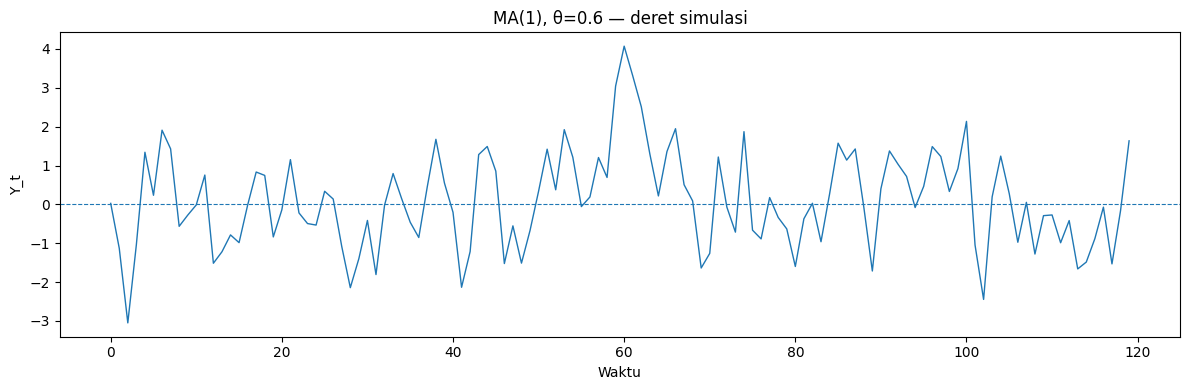

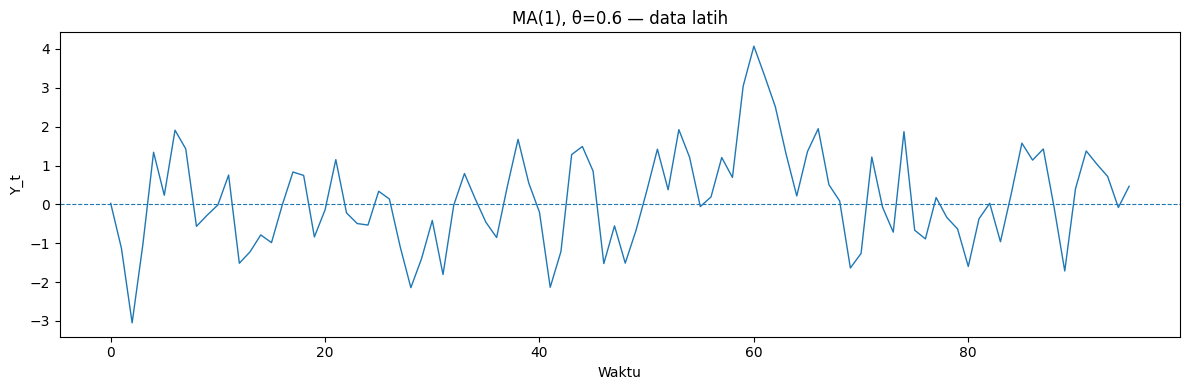

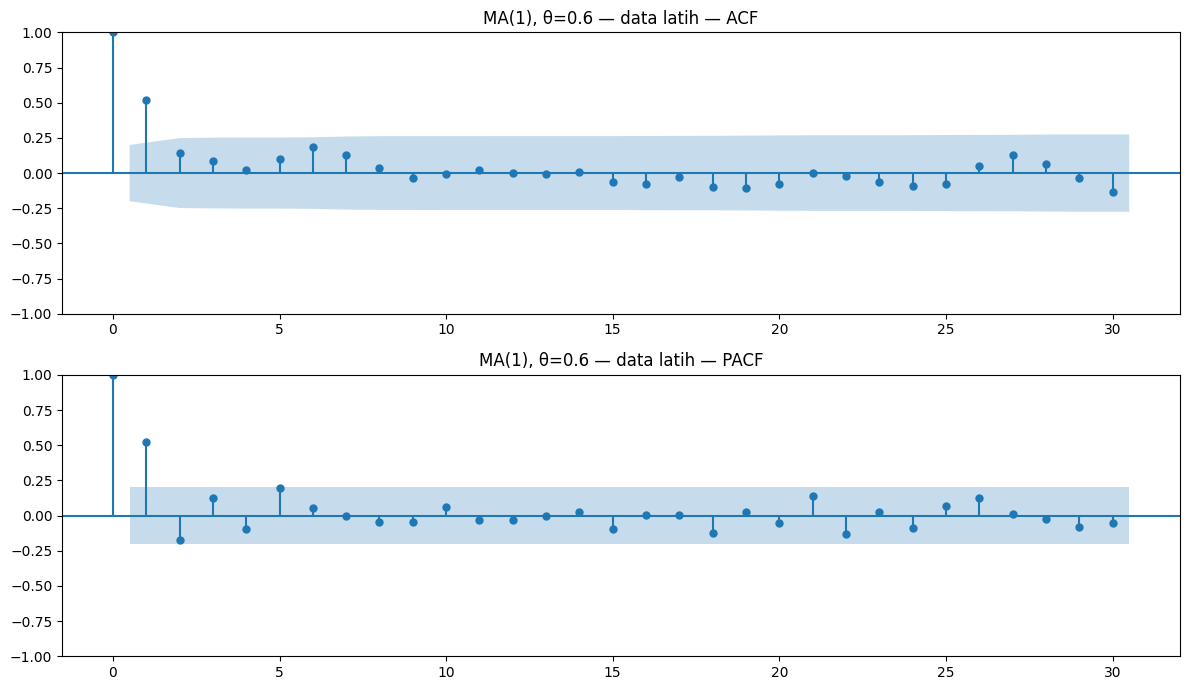

,q=0,q=1,q=2,q=3,q=4,q=5
p=0,—,x,o,o,o,o
p=1,—,o,o,o,o,o
p=2,—,o,o,o,o,o
p=3,—,o,o,o,o,o
p=4,—,o,o,o,o,o
p=5,—,o,o,o,o,o


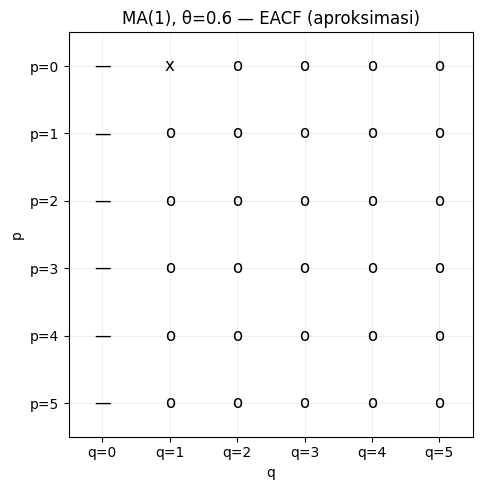

,Model,AIC,BIC,Ljung-Box p(10),Semua parameter signifikan
0,"ARIMA(0, 0, 1)",283.3749,288.5036,0.8772,True
1,"ARIMA(1, 0, 1)",284.7334,292.4264,0.9214,False
2,"ARIMA(0, 0, 2)",284.9067,292.5998,0.9146,False
3,"ARIMA(1, 0, 0)",288.2635,293.3922,0.4752,True
4,"ARIMA(2, 0, 0)",287.4539,295.1469,0.7046,False
5,"ARIMA(1, 0, 2)",285.4882,295.7456,0.9624,False
6,"ARIMA(2, 0, 1)",285.9571,296.2145,0.9495,False


Model terpilih berdasarkan BIC: ARIMA(0, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -139.687
Date:                Wed, 23 Sep 2026   AIC                            283.375
Time:                        01:31:34   BIC                            288.504
Sample:                             0   HQIC                           285.448
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6242      0.083      7.546      0.000       0.462       0.786
sigma2         1.0694      0.147      7.267      0.000       0.781       1.358
Ljung

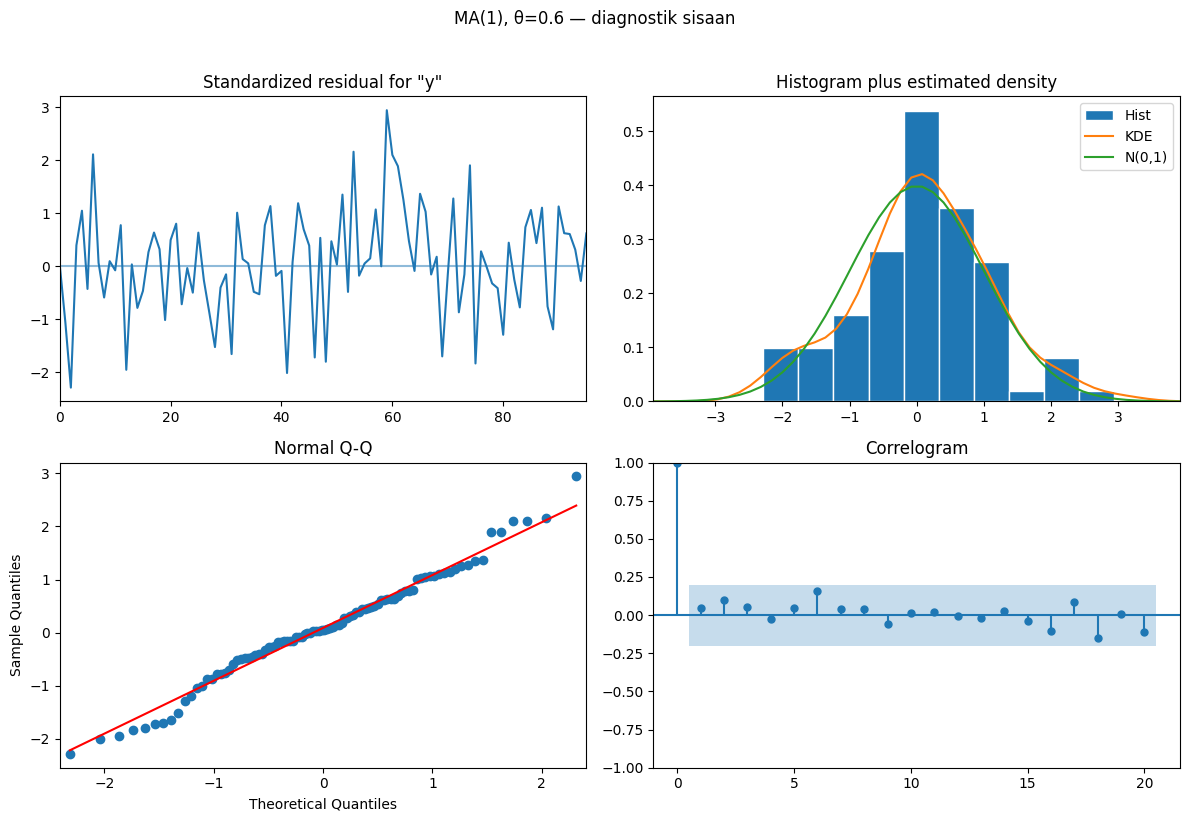

,lb_stat,lb_pvalue
10,5.203418,0.877182
15,5.580793,0.985962
20,11.808196,0.922519


p-value ARCH: 0.20070191701178247
p-value Shapiro-Wilk: 0.4432798265219888


,Data,MAPE,RMSE
0,Latih,193.2353,1.0403
1,Uji,98.8782,1.1483


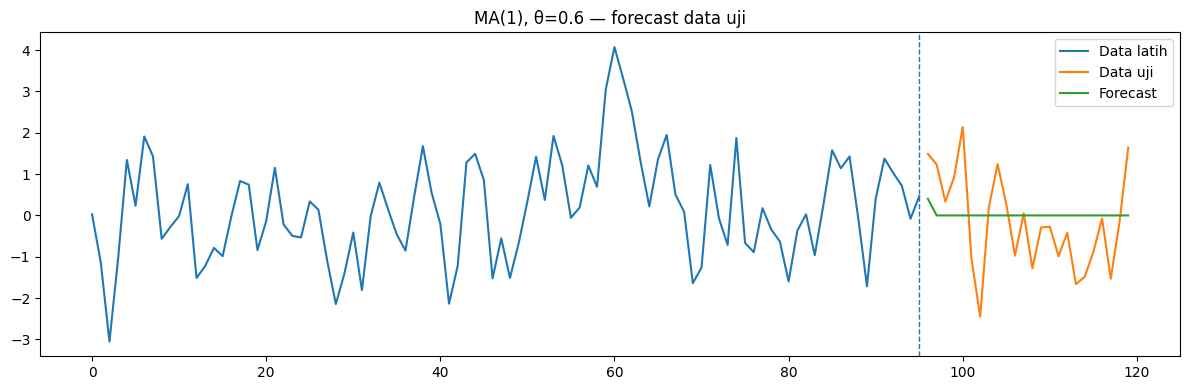

In [ ]:
ma1 = simulate_ma1(theta=0.6, n=120, seed=SEED)
res_ma1 = analyze_simulation('MA(1), θ=0.6', ma1)

### 2. AR(2), φ₁ = 0,9 dan φ₂ = −0,5, n = 100
Model teoritis: $Y_t=0,9Y_{t-1}-0,5Y_{t-2}+e_t$. Proses ini digunakan sebagai deret stasioner sesuai parameter yang diberikan.


AR(2), φ1=0.9, φ2=-0.5: n=100, train=80, test=20


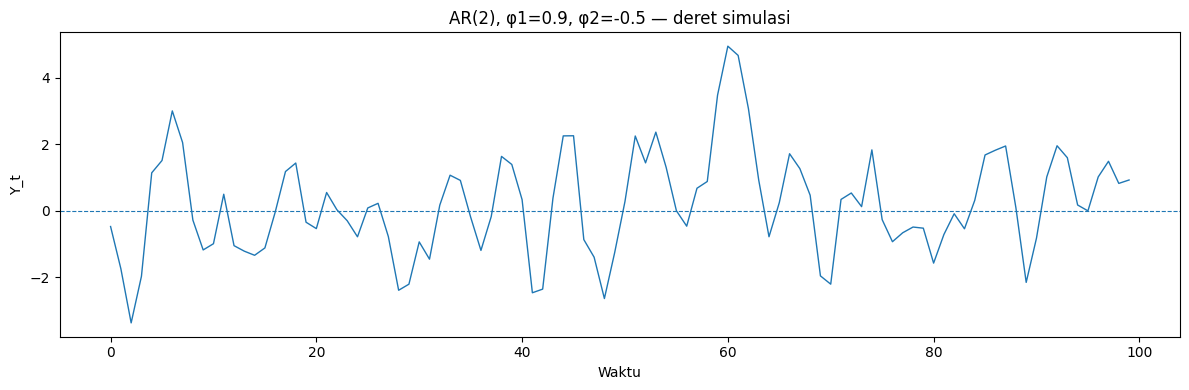

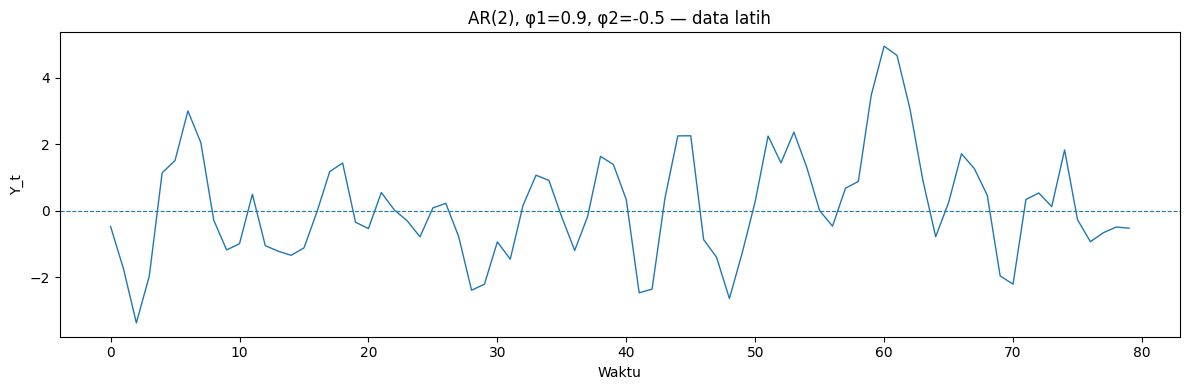

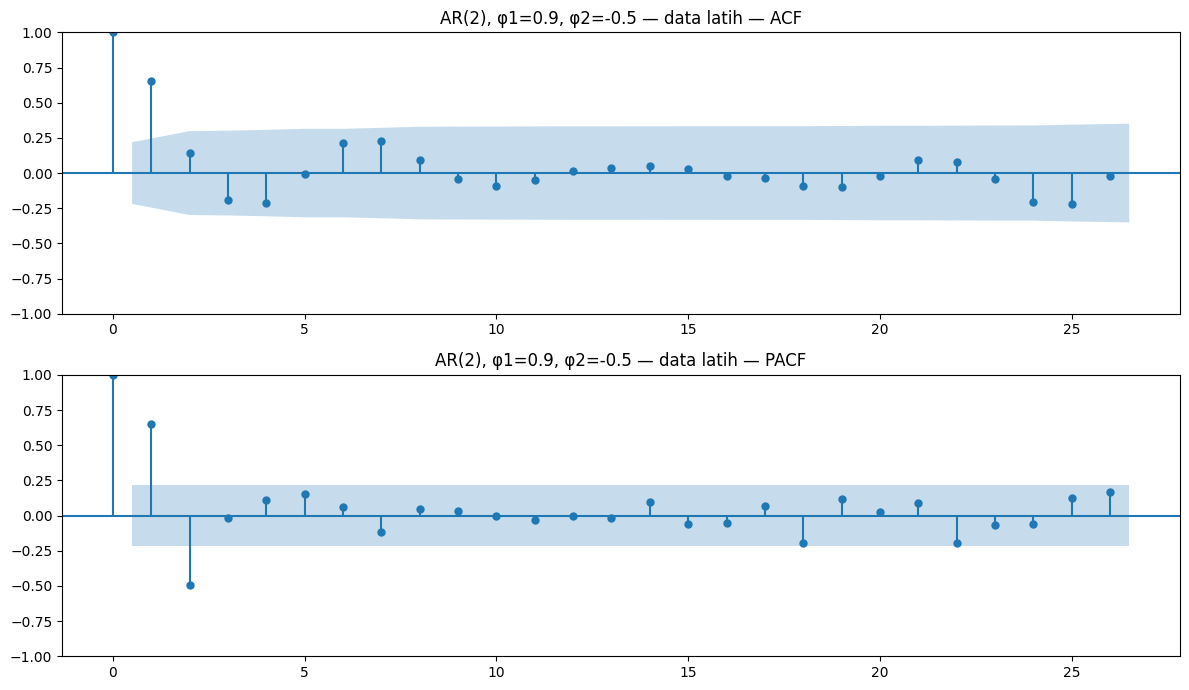

,q=0,q=1,q=2,q=3,q=4,q=5
p=0,—,x,o,o,o,o
p=1,—,x,o,x,x,o
p=2,—,o,o,o,o,o
p=3,—,o,o,o,o,o
p=4,—,o,o,o,o,o
p=5,—,o,o,o,o,o


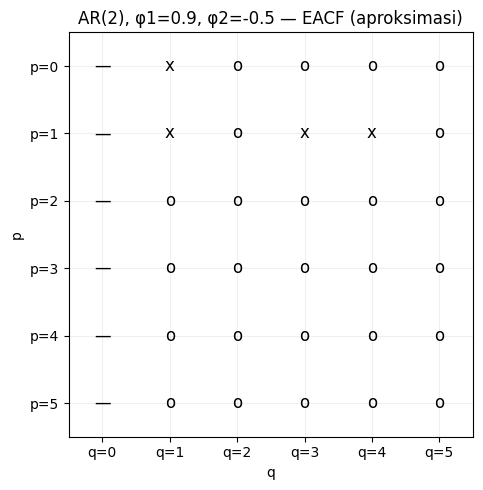

,Model,AIC,BIC,Ljung-Box p(10),Semua parameter signifikan
0,"ARIMA(2, 0, 0)",243.2999,250.4460,0.9323,True
1,"ARIMA(2, 0, 1)",245.2824,254.8105,0.9285,False
2,"ARIMA(0, 0, 2)",247.7666,254.9127,0.4410,True
3,"ARIMA(1, 0, 1)",250.5280,257.6741,0.0712,True
4,"ARIMA(1, 0, 2)",249.0570,258.5851,0.4288,False
5,"ARIMA(0, 0, 1)",259.6849,264.4489,0.0079,True
6,"ARIMA(1, 0, 0)",263.2686,268.0327,0.0000,True


Model terpilih berdasarkan BIC: ARIMA(2, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -118.650
Date:                Wed, 23 Sep 2026   AIC                            243.300
Time:                        01:32:06   BIC                            250.446
Sample:                             0   HQIC                           246.165
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9703      0.107      9.073      0.000       0.761       1.180
ar.L2         -0.4881      0.116     -4.219      0.000      -0.715      -0.261
sigma

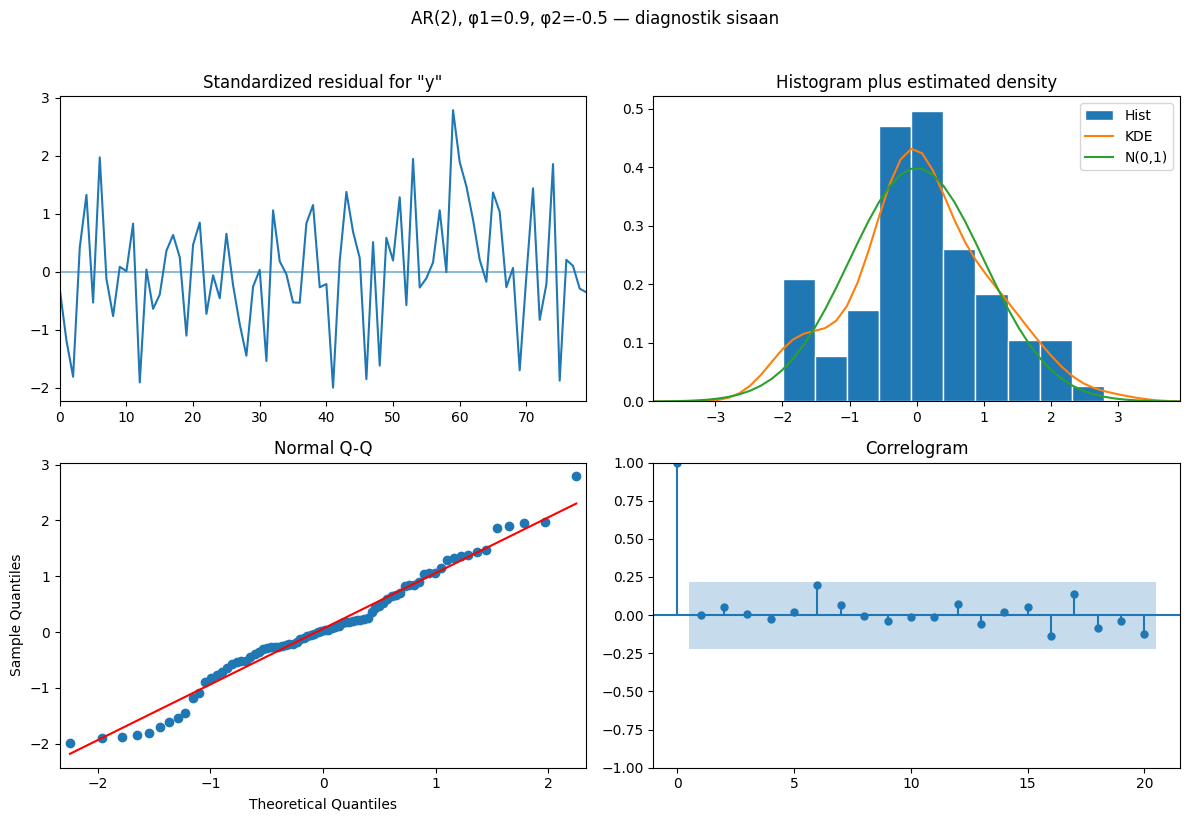

,lb_stat,lb_pvalue
10,4.309487,0.932307
15,5.578302,0.985995
20,11.929600,0.918478


p-value ARCH: 0.29201082267531514
p-value Shapiro-Wilk: 0.25283648730540176


,Data,MAPE,RMSE
0,Latih,228.4150,1.0625
1,Uji,105.8362,1.2331


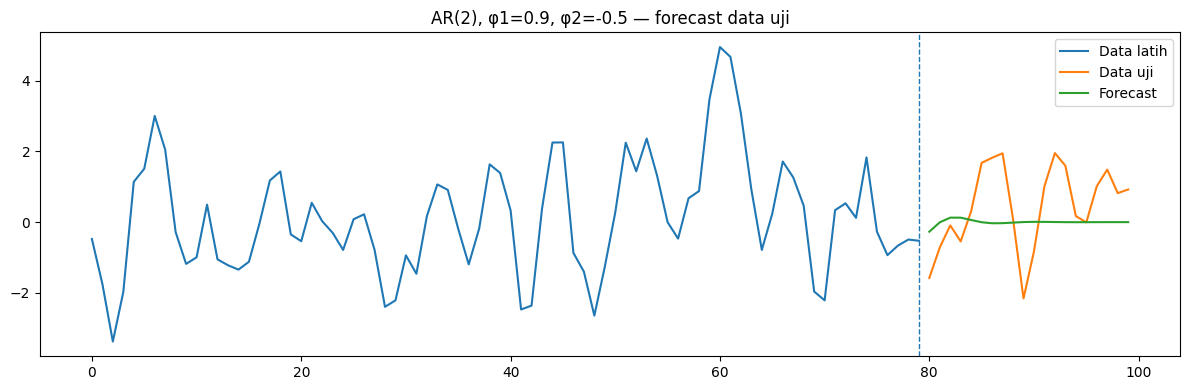

In [ ]:
ar2 = simulate_ar2(phi1=0.9, phi2=-0.5, n=100, seed=SEED)
res_ar2 = analyze_simulation('AR(2), φ1=0.9, φ2=-0.5', ar2)

### 3. ARMA(1,1), φ = 0,4 dan θ = 0,6, n = 200
Model teoritis: $Y_t=0,4Y_{t-1}+e_t+0,6e_{t-1}$. Karena |φ|<1, proses ARMA(1,1) ini stasioner.

Seed yang digunakan = 120

ARMA(1,1), φ=0.4, θ=0.6: n=200, train=160, test=40


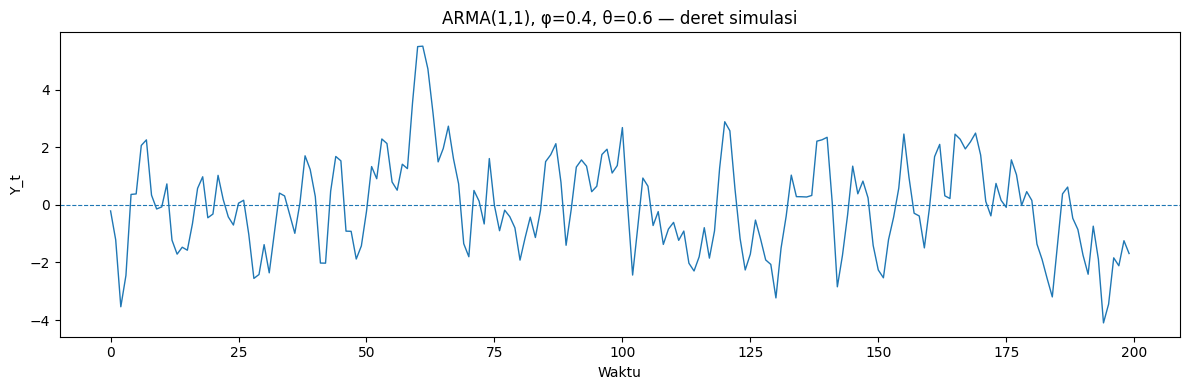

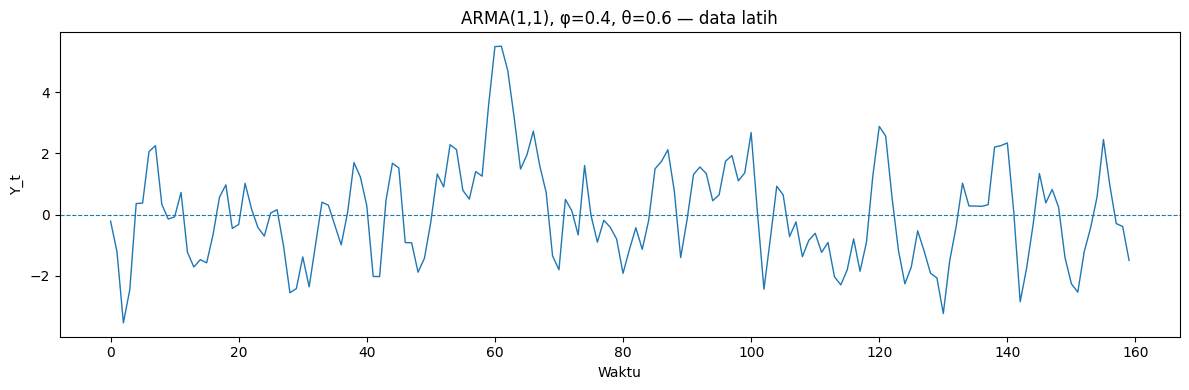

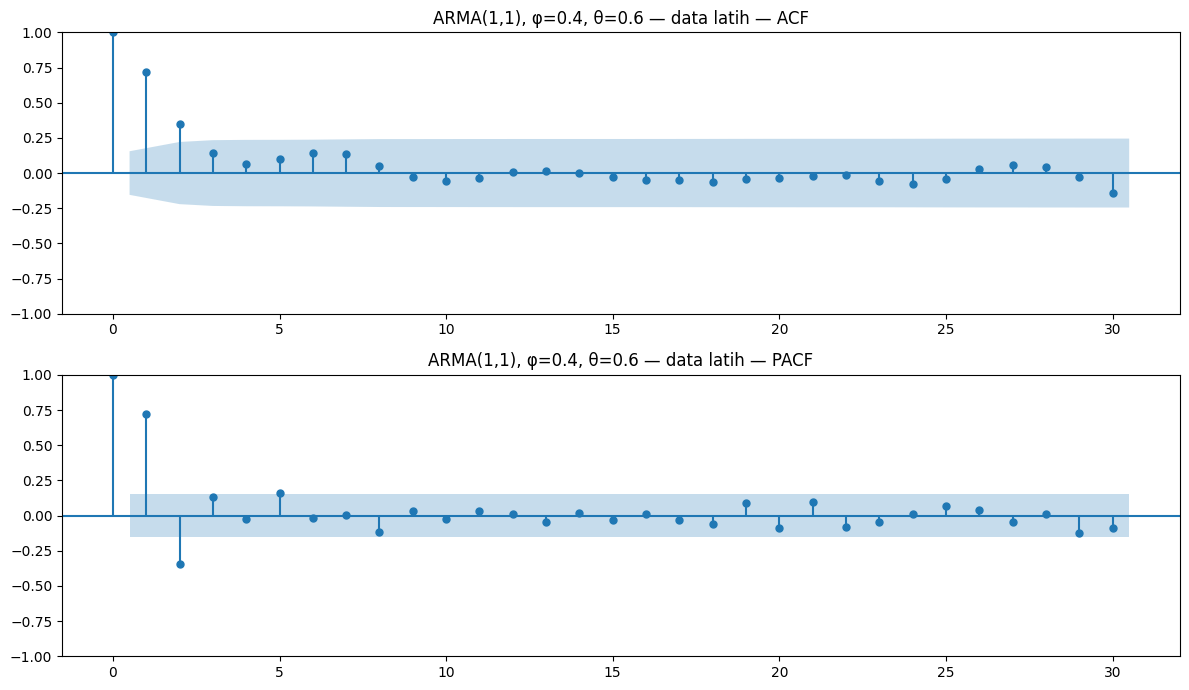

,q=0,q=1,q=2,q=3,q=4,q=5
p=0,—,x,x,o,o,o
p=1,—,x,x,x,x,o
p=2,—,o,o,o,o,o
p=3,—,o,o,o,o,o
p=4,—,o,o,o,o,o
p=5,—,o,o,o,o,o


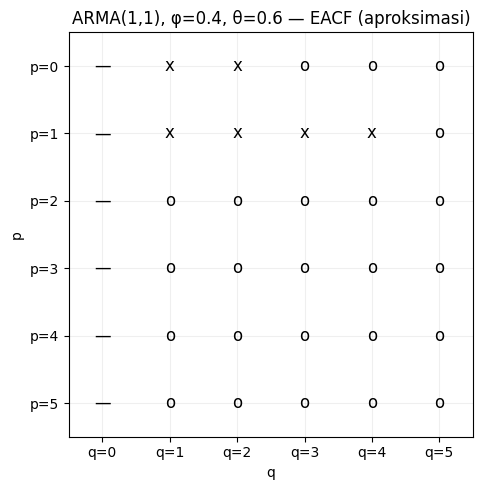

,Model,AIC,BIC,Ljung-Box p(10),Semua parameter signifikan
0,"ARIMA(1, 0, 1)",471.0640,480.2896,0.8935,True
1,"ARIMA(2, 0, 0)",475.8992,485.1247,0.6429,True
2,"ARIMA(2, 0, 1)",473.0565,485.3572,0.8887,False
3,"ARIMA(1, 0, 2)",473.0600,485.3607,0.8910,False
4,"ARIMA(0, 0, 2)",478.2419,487.4674,0.2930,True
5,"ARIMA(0, 0, 1)",494.9271,501.0775,0.0002,True
6,"ARIMA(1, 0, 0)",495.1803,501.3306,0.0005,True


Model terpilih berdasarkan BIC: ARIMA(1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -232.532
Date:                Wed, 23 Sep 2026   AIC                            471.064
Time:                        02:28:51   BIC                            480.290
Sample:                             0   HQIC                           474.810
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4943      0.084      5.869      0.000       0.329       0.659
ma.L1          0.5524      0.084      6.561      0.000       0.387       0.717
sigma

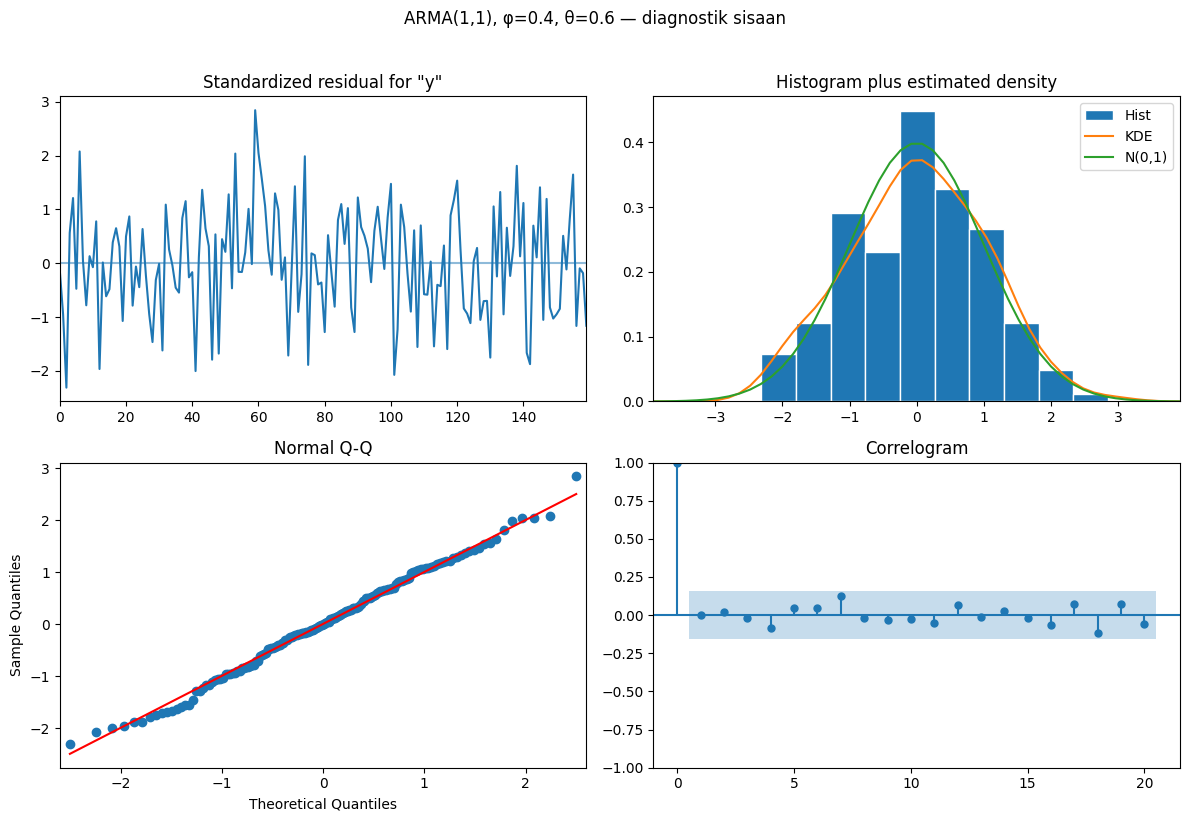

,lb_stat,lb_pvalue
10,4.964690,0.893524
15,6.503847,0.969986
20,12.218177,0.908362


p-value ARCH: 0.587615529847992
p-value Shapiro-Wilk: 0.7246273365198039


,Data,MAPE,RMSE
0,Latih,227.6233,1.0357
1,Uji,134.1704,1.7800


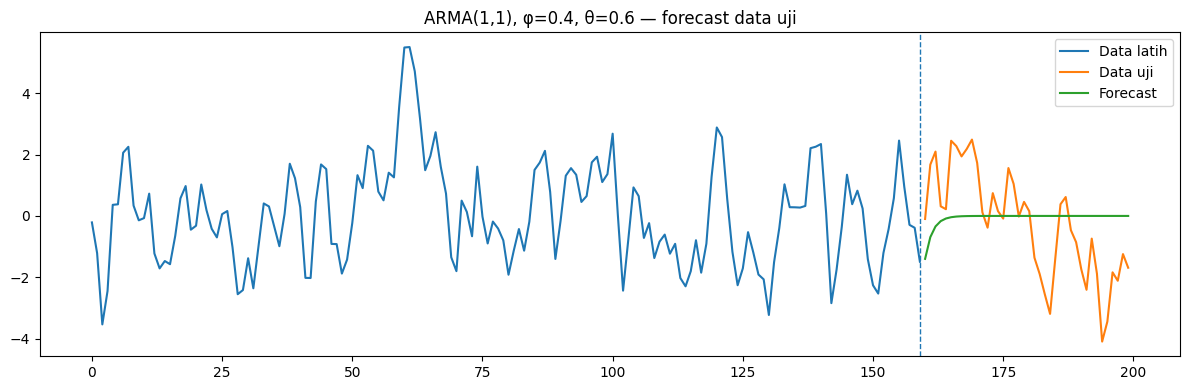

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import shapiro
from sklearn.metrics import root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==============================
# DEFINISI SEED UNTUK KELOMPOK
# Dipindahkan dari cell b2P-L9iu4iS2 untuk kemandirian cell ini.
# ==============================
LAST_2_DIGITS = [33+37+50]  # GANTI: 2 digit terakhir NIM SEMUA anggota kelompok
SEED = int(sum(LAST_2_DIGITS))
print('Seed yang digunakan =', SEED)

def simulate_ma1(theta, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(1, n + 200):
        y[t] = e[t] + theta * e[t-1]
    return y[200:]


def simulate_ar2(phi1, phi2, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(2, n + 200):
        y[t] = phi1*y[t-1] + phi2*y[t-2] + e[t]
    return y[200:]


def simulate_arma11(phi, theta, n, seed):
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, n + 200)
    y = np.zeros(n + 200)
    for t in range(1, n + 200):
        y[t] = phi*y[t-1] + e[t] + theta*e[t-1]
    return y[200:]


def mape_safe(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    mask = np.abs(actual) > 1e-8
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100


def plot_series(y, title):
    plt.figure(figsize=(12,4))
    plt.plot(y, linewidth=1)
    plt.axhline(0, linestyle='--', linewidth=0.8)
    plt.title(title)
    plt.xlabel('Waktu'); plt.ylabel('Y_t')
    plt.tight_layout(); plt.show()


def plot_acf_pacf(y, title, lags=30):
    fig, ax = plt.subplots(2, 1, figsize=(12,7))
    sm.graphics.tsa.plot_acf(y, lags=lags, ax=ax[0])
    sm.graphics.tsa.plot_pacf(y, lags=lags, ax=ax[1], method='ywm')
    ax[0].set_title(title + ' — ACF')
    ax[1].set_title(title + ' — PACF')
    plt.tight_layout(); plt.show()


def eacf_approx(y, max_p=5, max_q=5):
    """EACF-like table: residual ACF after fitting AR(p).
    'o' = residual autocorrelation at lag q tidak signifikan;
    'x' = masih signifikan. Ini digunakan sebagai pendekatan EACF
    ketika fungsi EACF khusus tidak tersedia di Python.
    """
    y = np.asarray(y)
    out = np.empty((max_p+1, max_q+1), dtype=object)
    out[:] = ''
    n = len(y)
    crit = 1.96 / np.sqrt(n)
    for p in range(max_p+1):
        if p == 0:
            resid = y - np.mean(y)
        else:
            fit = ARIMA(y, order=(p,0,0), trend='c').fit()
            resid = fit.resid
        ac = acf(resid, nlags=max_q, fft=False)
        for q in range(max_q+1):
            if q == 0:
                out[p,q] = '—'
            else:
                out[p,q] = 'o' if abs(ac[q]) <= crit else 'x'
    return pd.DataFrame(out, index=[f'p={p}' for p in range(max_p+1)],
                        columns=[f'q={q}' for q in range(max_q+1)])


def plot_eacf(table, title):
    num = table.shape[1]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.imshow(np.zeros((table.shape[0], table.shape[1])), cmap='Greys', alpha=0)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, table.iloc[i,j], ha='center', va='center', fontsize=12)
    ax.set_xticks(range(num)); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index)
    ax.set_xlabel('q'); ax.set_ylabel('p')
    ax.set_title(title + ' — EACF (aproksimasi)')
    ax.grid(True, alpha=.2)
    plt.tight_layout(); plt.show()


def fit_candidates(train):
    orders = [(0,0,1),(1,0,0),(2,0,0),(0,0,2),(1,0,1),(2,0,1),(1,0,2)]
    records = []
    fits = {}
    for order in orders:
        try:
            fit = ARIMA(train, order=order, trend='n').fit()
            lb = acorr_ljungbox(fit.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
            records.append({
                'Model': f'ARIMA{order}', 'AIC': fit.aic, 'BIC': fit.bic,
                'Ljung-Box p(10)': lb,
                'Semua parameter signifikan': bool(np.all(fit.pvalues < 0.05))
            })
            fits[order] = fit
        except Exception:
            pass
    table = pd.DataFrame(records).sort_values('BIC').reset_index(drop=True)
    return table, fits


def diagnostics(fit):
    lb = acorr_ljungbox(fit.resid, lags=[10,15,20], return_df=True)
    arch_p = het_arch(fit.resid, nlags=10)[1]
    shapiro_p = shapiro(fit.resid)[1]
    return lb, arch_p, shapiro_p


def analyze_simulation(name, y, split=0.8):
    n = len(y); n_train = int(np.floor(split*n))
    train, test = y[:n_train], y[n_train:]
    print(f'\n{name}: n={n}, train={len(train)}, test={len(test)}')
    plot_series(y, f'{name} — deret simulasi')
    plot_series(train, f'{name} — data latih')
    plot_acf_pacf(train, f'{name} — data latih', lags=min(30, len(train)//3))
    et = eacf_approx(train)
    display(et)
    plot_eacf(et, name)
    table, fits = fit_candidates(train)
    display(table.round(4))
    # Model dipilih terutama berdasarkan BIC, dengan AIC sebagai pembanding.
    best_order = table.iloc[0]['Model']
    order = eval(best_order.replace('ARIMA',''))
    fit = fits[order]
    print('Model terpilih berdasarkan BIC:', best_order)
    print(fit.summary())
    fit.plot_diagnostics(figsize=(12,8), lags=20)
    plt.suptitle(name + ' — diagnostik sisaan', y=1.02)
    plt.tight_layout(); plt.show()
    lb, arch_p, shapiro_p = diagnostics(fit)
    display(lb)
    print('p-value ARCH:', arch_p)
    print('p-value Shapiro-Wilk:', shapiro_p)
    # Forecast test
    pred_test = fit.get_forecast(steps=len(test)).predicted_mean
    pred_train = fit.fittedvalues
    train_actual = train[2:]
    train_pred = pred_train[2:]
    metrics = pd.DataFrame({
        'Data':['Latih','Uji'],
        'MAPE':[mape_safe(train_actual, train_pred), mape_safe(test, pred_test)],
        'RMSE':[root_mean_squared_error(train_actual, train_pred), root_mean_squared_error(test, pred_test)]
    })
    display(metrics.round(4))
    plt.figure(figsize=(12,4))
    plt.plot(np.arange(len(train)), train, label='Data latih')
    plt.plot(np.arange(len(train),n), test, label='Data uji')
    plt.plot(np.arange(len(train),n), pred_test, label='Forecast')
    plt.axvline(len(train)-1, linestyle='--', linewidth=1)
    plt.title(name + ' — forecast data uji')
    plt.legend(); plt.tight_layout(); plt.show()
    return {'train':train,'test':test,'table':table,'fit':fit,'metrics':metrics,'forecast':pred_test,'eacf':et}

# Existing code in the cell
arma11 = simulate_arma11(phi=0.4, theta=0.6, n=200, seed=SEED)
res_arma11 = analyze_simulation('ARMA(1,1), φ=0.4, θ=0.6', arma11)

## Interpretasi hasil

Berdasarkan analisis menggunakan metode Box–Jenkins, diperoleh beberapa kesimpulan.

1. Data simulasi MA(1) dengan (\theta=0.6) menghasilkan model terpilih ARIMA(0,0,1). Parameter MA yang diperoleh sebesar 0.6242, yang relatif dekat dengan parameter simulasi 0.6.
2. Data simulasi AR(2) dengan (\phi_1=0.9) dan (\phi_2=-0.5) menghasilkan model ARIMA(2,0,0). Estimasi parameter menghasilkan (\hat{\phi}_1=0.9703) dan (\hat{\phi}_2=-0.4881), yang relatif dekat dengan parameter sebenarnya.
3. Data simulasi ARMA(1,1) dengan (\phi=0.4) dan (\theta=0.6) menghasilkan model ARIMA(1,0,1). Parameter yang diperoleh adalah (\hat{\phi}=0.4943) dan (\hat{\theta}=0.5524).
4. Ketiga model terpilih memiliki nilai BIC paling rendah dibandingkan kandidat model yang diuji.
5. Parameter model terpilih signifikan secara statistik berdasarkan hasil estimasi.
6. Uji Ljung–Box pada ketiga model menghasilkan p-value lebih besar dari 0.05 pada lag 10, sehingga tidak terdapat bukti adanya autokorelasi residual.
7. Uji ARCH juga tidak menunjukkan bukti heteroskedastisitas bersyarat pada ketiga model.
8. Hasil uji Shapiro–Wilk memberikan p-value lebih besar dari 0.05 untuk ketiga model sehingga tidak terdapat bukti yang cukup untuk menolak normalitas residual.
9. Model terpilih dapat menangkap struktur dasar proses simulasi karena bentuk model yang diperoleh sesuai dengan proses yang digunakan untuk membangkitkan data.
10. Nilai MAPE relatif besar karena data simulasi memiliki nilai aktual yang mendekati nol dan negatif.
